# Pseudobulk Enrichment Analysis
When cell identity clusters are well-defined, it can be advantageous to perform analyses at the pseudobulk level rather than at the single-cell level. Pseudobulking involves aggregating counts across cells of the same type within each sample, effectively creating sample-level gene expression profiles per cell type. This approach helps mitigate the effects of technical noise and dropouts common in single-cell data, enabling the detection of lowly expressed genes that might otherwise be missed.

Moreover, conducting differential expression analysis (DEA) at the pseudobulk level, treating each biological sample as the unit of observation, is statistically more robust. Unlike single-cell DEA, which assumes cells are independent (an assumption that is violated when cells originate from the same individual), sample-level pseudobulk analysis avoids inflation of p-values by reducing the number of observations and by correctly modeling biological replication {cite:p}psbulk.

The resulting gene-level statistics from pseudobulk DEA can then be used as input for downstream enrichment analyses.

In this notebook, we demonstrate how to use decoupler to infer transcription factor (TF) and pathway enrichment scores from a multi-sample scRNA-seq human dataset.



In [1]:
import scanpy as sc
import decoupler as dc

sc.set_figure_params(figsize=(3, 3), frameon=False)

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata = sc.read_h5ad('../data/ST_BRICHOS_region_subcluster.h5ad')

In [3]:
adata.X = adata.layers['counts']

In [4]:
adata.X = adata.X.astype(int)

In [5]:
adata.obs_names_make_unique()

In [6]:
adata

AnnData object with n_obs × n_vars = 25660 × 18751
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample', 'sample_id', 'n_genes', 'leiden', 'treatment', 'barcode', 'region_annotation', 'leiden_0.5', 'leiden_0.75', 'leiden_1', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'PIG_score', 'OLIG_score', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 're_annotation_regions'
    var: 'n_cells'
    uns: 'dendrogram_treatment', 'leiden', 'leiden_0.1_colors', 'leiden_0.2_colors', 'leiden_0.3_colors', 'leiden_0.5_colors', 'leiden_0.75_colors', 'leiden_1.5_colors', 'leiden_1_colors', 'leiden_2.5_colors', 'leiden_2_colors', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'region_annotation_colors', 'sample_id_colors', 'spatial', 'spatial_metadata_per_sample', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

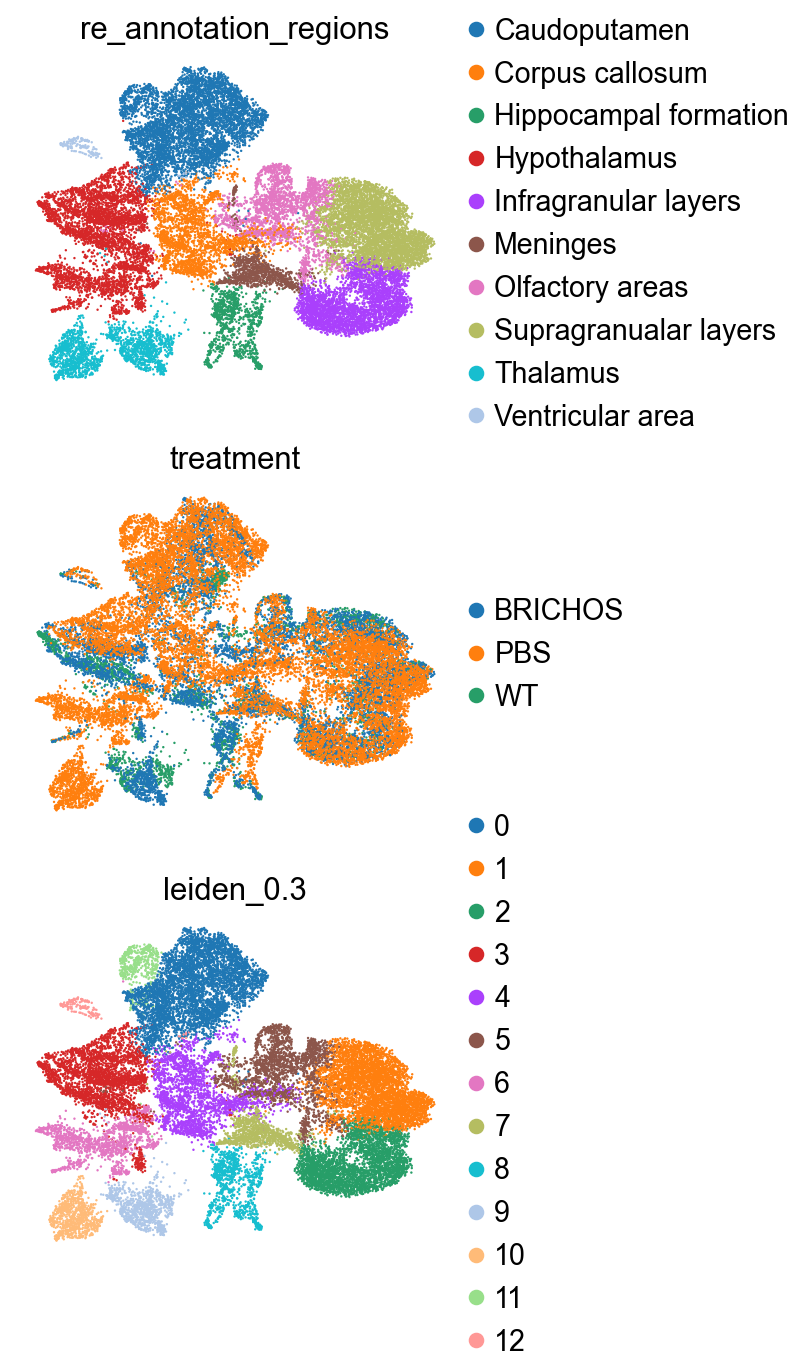

In [7]:
sc.pl.umap(adata, color=["re_annotation_regions", "treatment",'leiden_0.3'], ncols=1)

## Pseudobulking
The pseudo-bulk approach involves the following steps:

Subsetting the cell type of interest
Extracting their raw integer counts
Summing their counts per gene into a single profile if they pass quality control
Then, DEA can be performed if there are at least two biological replicates per condition (more replicates are recommended).

Pseudobulking can easily be performed using the function {func}decoupler.pp.pseudobulk. In this example, the counts are just summed, though other modes such as the mean or any custom aggregation function are available. For more information, refer to the mode argument.

In [8]:
pdata = dc.pp.pseudobulk(
    adata=adata,
    sample_col="sample_id",
    groups_col="leiden_0.3",
    mode="sum",
)

## Variability Exploration
With pseudobulk profiles generated for each cell type and sample, variability across them can now be explored.

This involves some basic preprocessing followed by principal component analysis (PCA).

In [9]:
# Store raw counts in layers
pdata.layers["counts"] = pdata.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X
dc.pp.swap_layer(adata=pdata, key="counts", inplace=True)

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [10]:
del pdata.obs['in_tissue']

In [11]:
dc.tl.rankby_obsm(pdata, key="X_pca")

In [12]:
pdata.obs

,sample_id,leiden_0.3,sample,treatment,re_annotation_regions,psbulk_cells,psbulk_counts
P24215_101_0,P24215_101,0,P24215_101,WT,Caudoputamen,321.0,3378459.0
P24215_201_0,P24215_201,0,P24215_201,BRICHOS,Caudoputamen,155.0,1661362.0
P24215_301_0,P24215_301,0,P24215_301,BRICHOS,Caudoputamen,533.0,6343110.0
P28052_102_0,P28052_102,0,P28052_102,PBS,Caudoputamen,18.0,281450.0
P28052_103_0,P28052_103,0,P28052_103,PBS,Caudoputamen,7.0,193979.0
...,...,...,...,...,...,...,...
P28052_201_9,P28052_201,9,P28052_201,PBS,Olfactory areas,0.0,0.0
P28052_202_9,P28052_202,9,P28052_202,PBS,Corpus callosum,0.0,0.0
P28052_203_9,P28052_203,9,P28052_203,PBS,Supragranualar layers,0.0,0.0
P28052_301_9,P28052_301,9,P28052_301,PBS,Infragranular layers,0.0,0.0


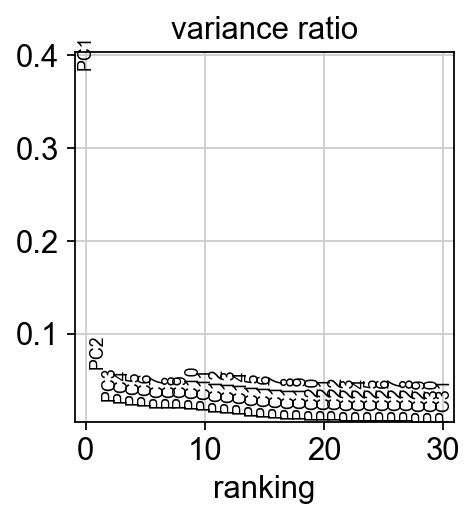

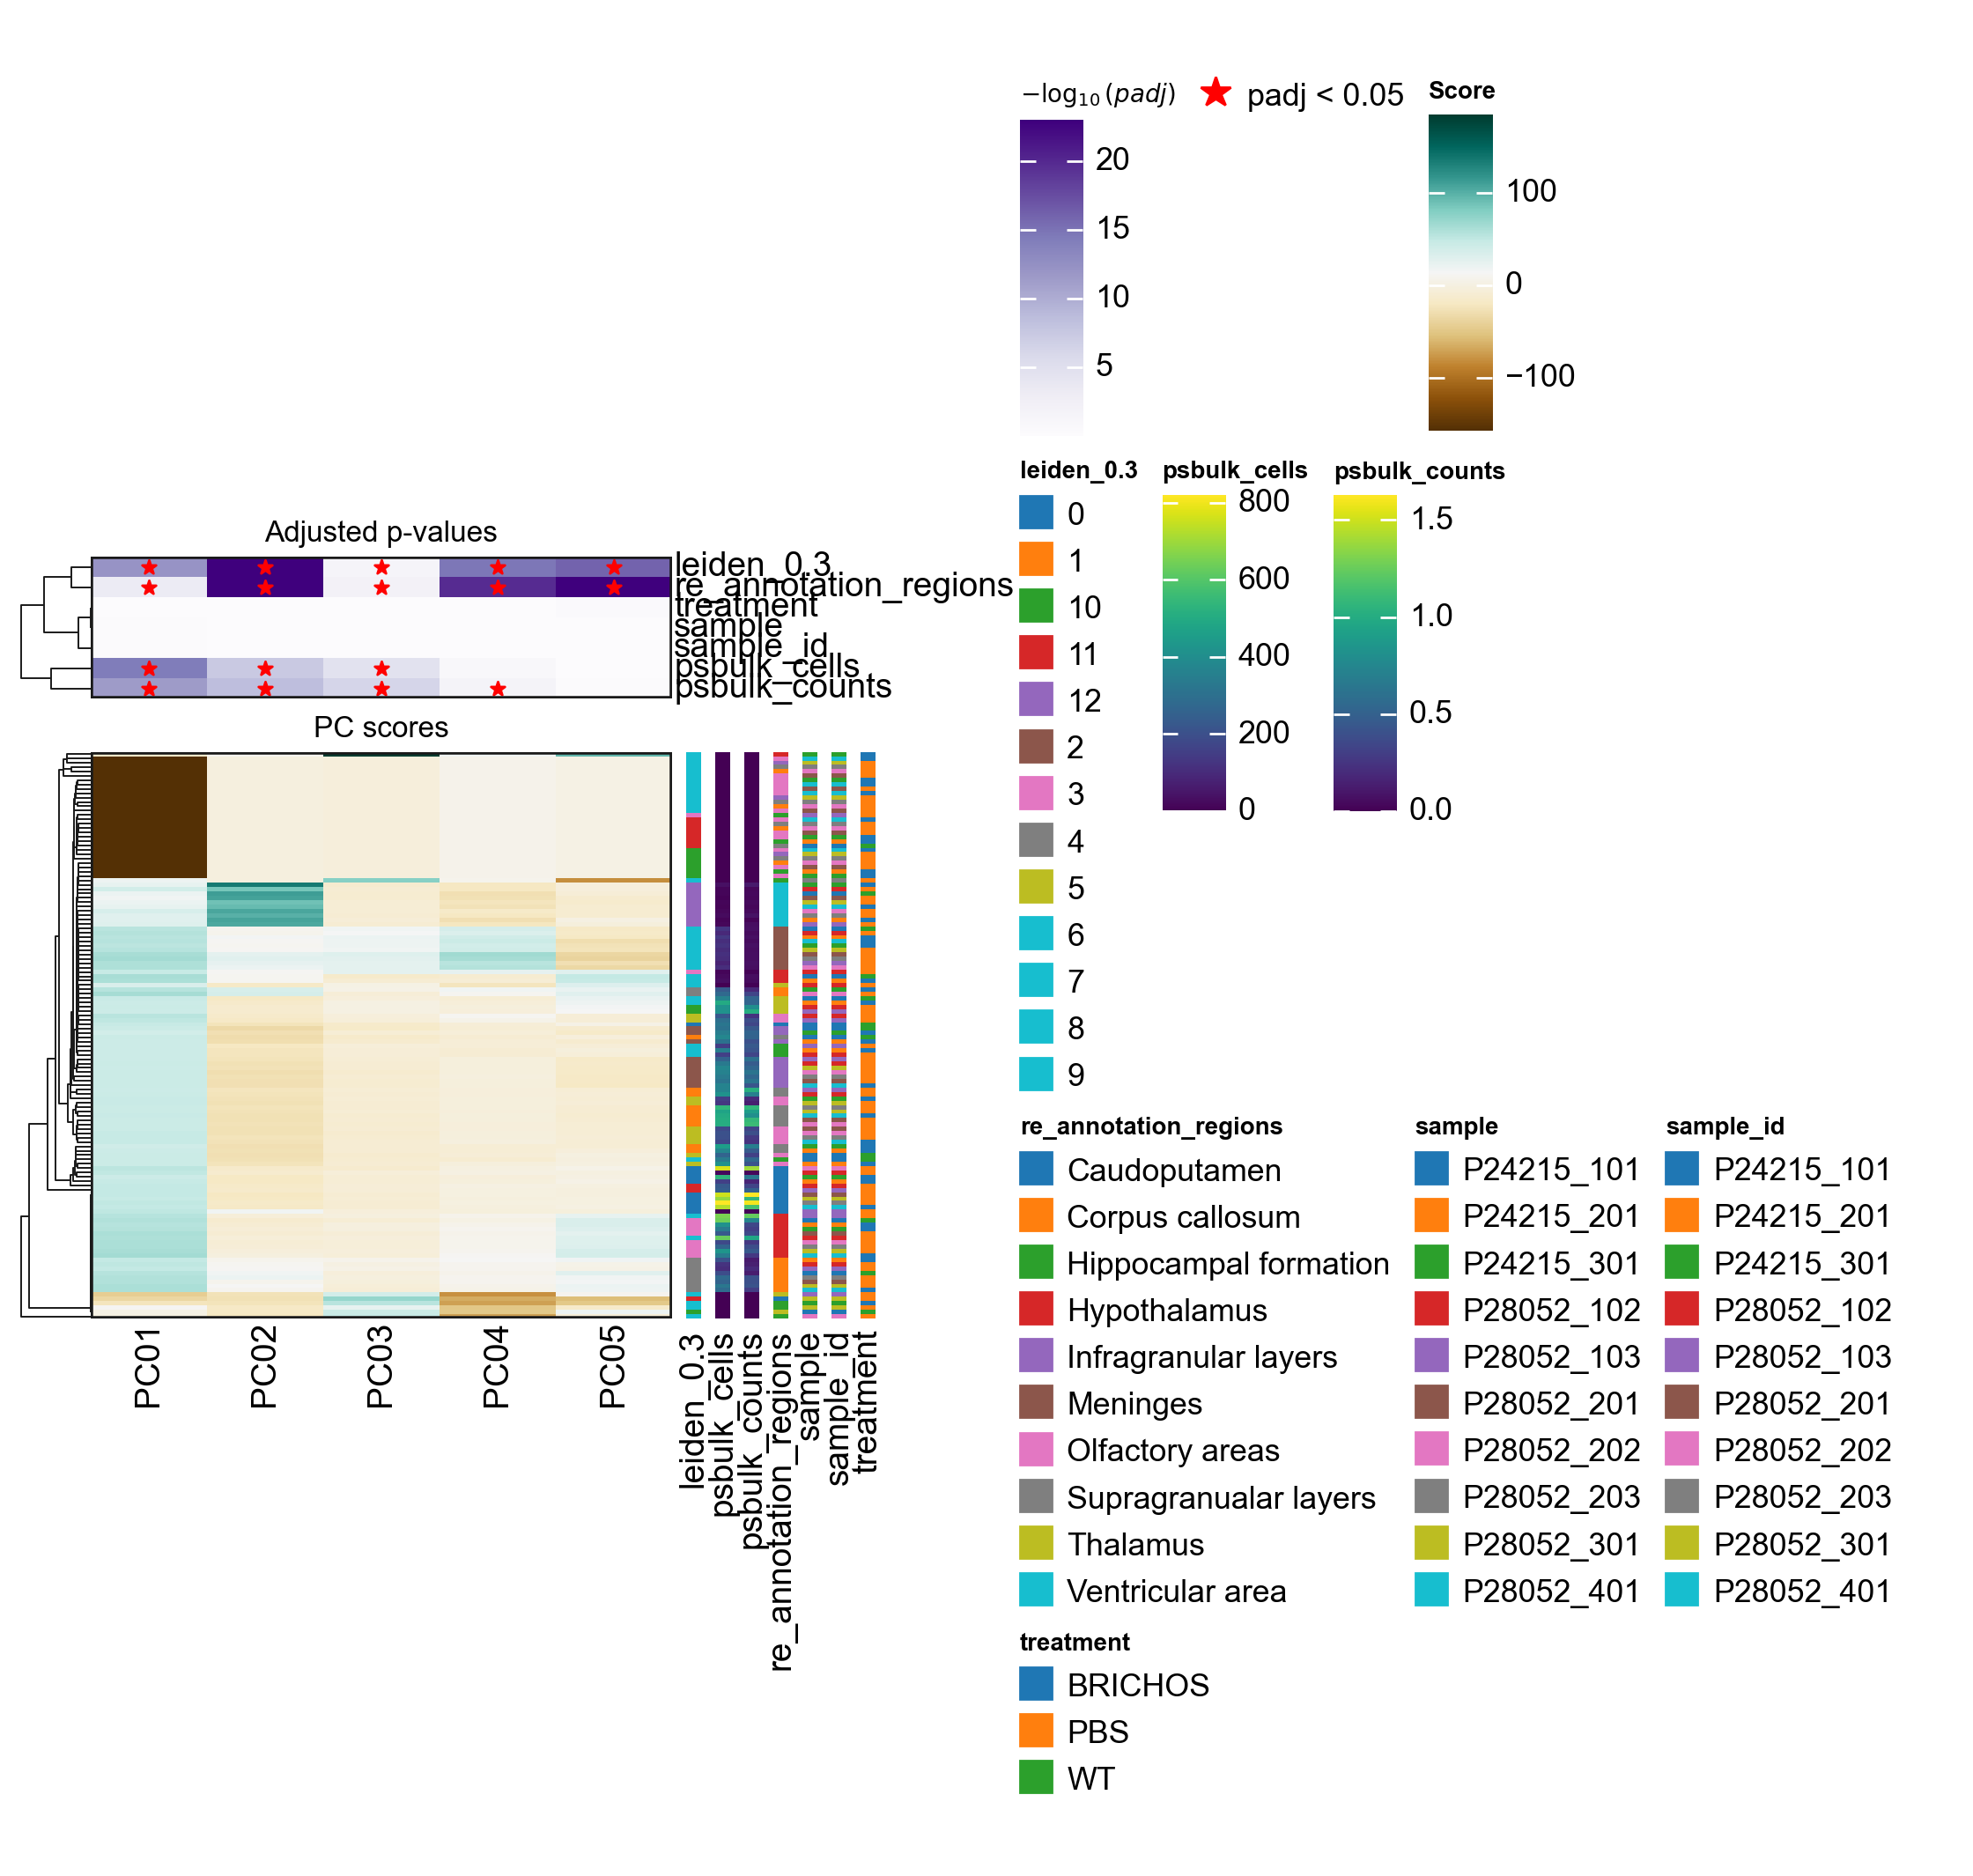

In [13]:
sc.pl.pca_variance_ratio(pdata)
dc.pl.obsm(adata=pdata, return_fig=True, nvar=5, titles=["PC scores", "Adjusted p-values"], figsize=(10, 5))

In [14]:
pdata.obs

,sample_id,leiden_0.3,sample,treatment,re_annotation_regions,psbulk_cells,psbulk_counts
P24215_101_0,P24215_101,0,P24215_101,WT,Caudoputamen,321.0,3378459.0
P24215_201_0,P24215_201,0,P24215_201,BRICHOS,Caudoputamen,155.0,1661362.0
P24215_301_0,P24215_301,0,P24215_301,BRICHOS,Caudoputamen,533.0,6343110.0
P28052_102_0,P28052_102,0,P28052_102,PBS,Caudoputamen,18.0,281450.0
P28052_103_0,P28052_103,0,P28052_103,PBS,Caudoputamen,7.0,193979.0
...,...,...,...,...,...,...,...
P28052_201_9,P28052_201,9,P28052_201,PBS,Olfactory areas,0.0,0.0
P28052_202_9,P28052_202,9,P28052_202,PBS,Corpus callosum,0.0,0.0
P28052_203_9,P28052_203,9,P28052_203,PBS,Supragranualar layers,0.0,0.0
P28052_301_9,P28052_301,9,P28052_301,PBS,Infragranular layers,0.0,0.0


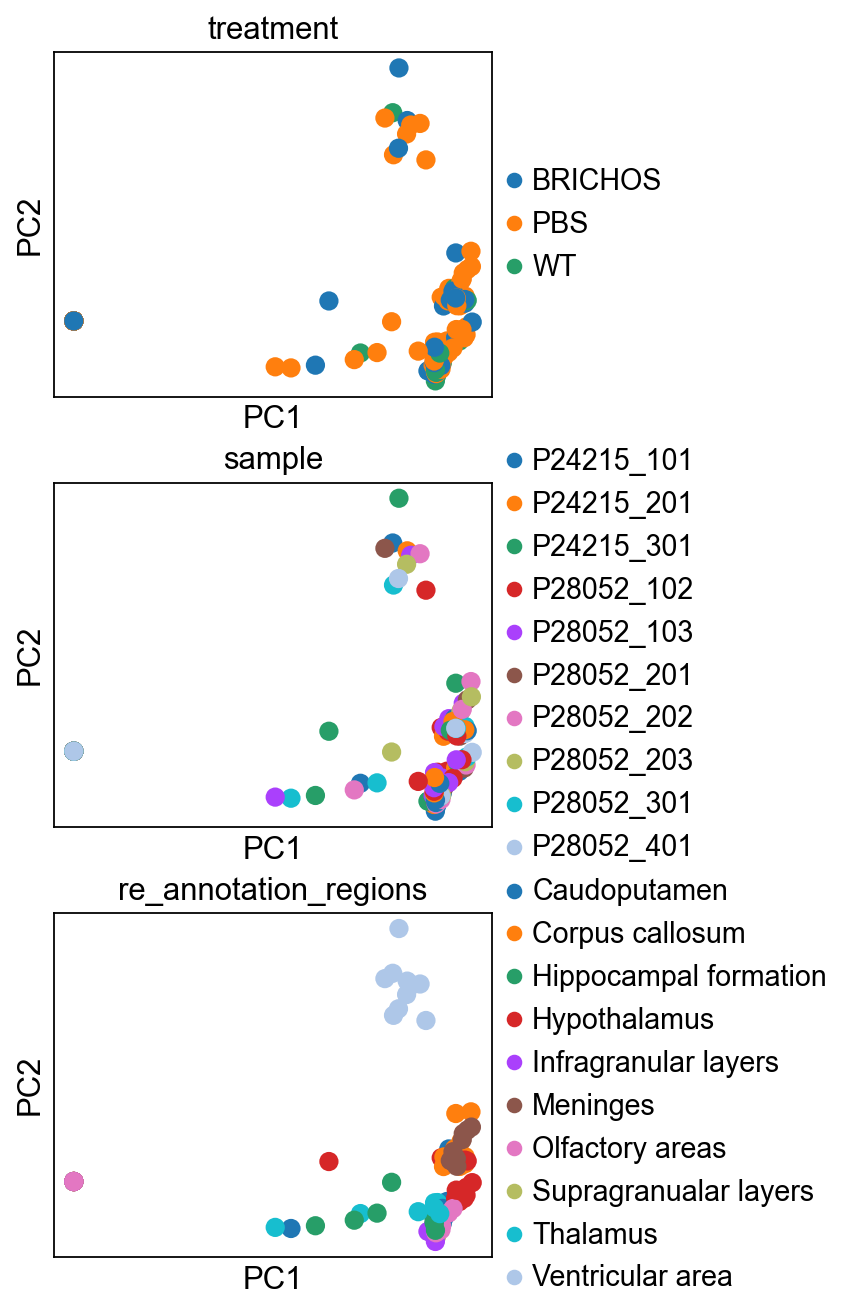

In [15]:
sc.pl.pca(
    pdata,
    color=[ "treatment", 'sample', 're_annotation_regions'],
    ncols=1,
    size=300,
    frameon=True,
)

In [16]:
OL = pdata[pdata.obs.treatment != 'WT']

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/views.py:151: RuntimeWarning: invalid value encountered in divide
  results = super().__array_ufunc__(


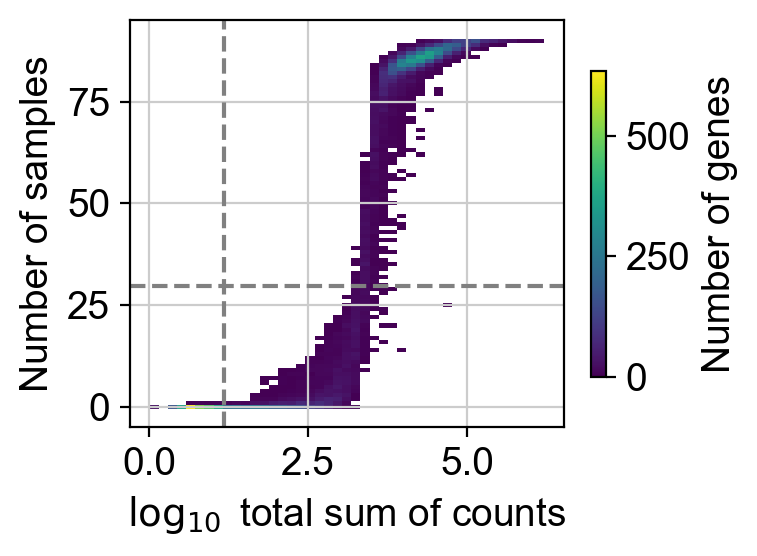

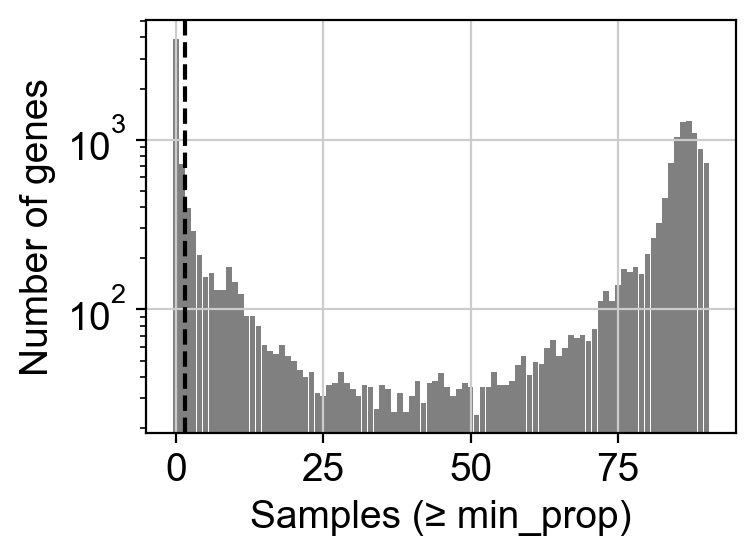

In [17]:
dc.pl.filter_by_expr(
    adata=OL,
    group="treatment",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pl.filter_by_prop(
    adata=OL,
    min_prop=0.1,
    min_smpls=2,
)

In [ ]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=OL,
    design_factors=["treatment"],
    refit_cooks=True,
    inference=inference,
)

# Compute LFCs
dds.deseq2()

# Extract contrast between conditions
stat_res = DeseqStats(dds, contrast=["treatment", "BRICHOS", "PBS"], inference=inference)

# Compute Wald test
stat_res.summary()

Using None as control genes, passed at DeseqDataSet initialization


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/dds.py:244: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  self.X = adata.X.astype(int)
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_21126/525949512.py:7: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/dds.py:299: ImplicitModificationWarning: Setting element `.obsm['design_matrix']` of view, initializing view as actual.
  self.obsm["design_matrix"] = self.formulaic_contrasts.design_matrix
Fitting size factors...
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/dds.py:532: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors(


In [ ]:
# Extract results
results_df = stat_res.results_df
results_df

In [22]:
OL.obs

,sample_id,leiden_0.3,sample,condition,re_annotation_regions,psbulk_cells,psbulk_counts
P24215_201_0,P24215_201,0,P24215_201,BRICHOS,Caudoputamen,155.0,1661362.0
P24215_301_0,P24215_301,0,P24215_301,BRICHOS,Caudoputamen,533.0,6343110.0
P28052_102_0,P28052_102,0,P28052_102,PBS,Caudoputamen,18.0,281450.0
P28052_103_0,P28052_103,0,P28052_103,PBS,Caudoputamen,7.0,193979.0
P28052_201_0,P28052_201,0,P28052_201,PBS,Caudoputamen,756.0,16230641.0
...,...,...,...,...,...,...,...
P28052_201_9,P28052_201,9,P28052_201,PBS,Olfactory areas,0.0,0.0
P28052_202_9,P28052_202,9,P28052_202,PBS,Corpus callosum,0.0,0.0
P28052_203_9,P28052_203,9,P28052_203,PBS,Supragranualar layers,0.0,0.0
P28052_301_9,P28052_301,9,P28052_301,PBS,Infragranular layers,0.0,0.0


In [ ]:
OL.obs = OL.obs.rename(columns= {'treatment':'condition'})

In [ ]:
# Build DESeq2 dataset
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=OL,
    metadata="condition",               # column in adata.obs
    ref_level=["condition", "BRICHOS"], # reference level
    refit_cooks=True,
    inference=inference,
)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import matplotlib.pyplot as plt
import decoupler as dc

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 6)    
dc.pl.volcano(
        results_df,
        x="log2FoldChange",
        y="pvalue",
        top=20,
    figsize=(12, 8)
    )

In [ ]:
data = results_df[["stat"]].T.rename(index={"stat": "disease.vs.normal"})
data

## Enrichment analysis
Enrichment analysis tests whether a specific set of omics features is "overrepresented" or "coordinated" in the measured data compared to a background distribution. These sets are predefined based on existing biological knowledge and may vary depending on the omics technology used.

Enrichment analysis requires the use of an enrichment method, and several options are available. In the original manuscript of decoupler {cite:p}decoupler, we benchmarked multiple methods and found that the univariate linear model (ulm) outperformed the others. Therefore, we will use ulm in this vignette.

The scores from {func}decoupler.mt.ulm should be interpreted such that larger magnitudes indicate greater significance, while the sign reflects whether the features in the set are overrepresented (positive) or underrepresented (negative) compared to the background.

Transcription factor scoring from gene regulatory networks
Transcription factors (TFs) are genes that, once translated into proteins, bind to DNA and regulate the expression of other genes by either promoting or inhibiting their transcription. Gene Regulatory Networks (GRNs) capture these TF-gene interactions and can be constructed from prior knowledge or inferred from omics data. The fundamental unit of a GRN is a TF and its associated target genes, collectively known as a regulon. Each regulon functions as a gene set in enrichment analysis.

Although TFs are measured in transcriptomic data, their transcript levels often do not reflect their actual activity in a given cell. Instead, scoring TFs through enrichment analysis based on the expression of their target genes provides a more accurate representation of their regulatory activity {cite:p}grn_review.

CollecTRI network
CollecTRI is a comprehensive resource containing a curated collection of TFs and their transcriptional targets compiled from 12 different resources {cite:p}collectri. This collection provides an increased coverage of transcription factors and a superior performance in identifying perturbed TFs compared to other literature based GRNs such as DoRothEA {cite:p}dorothea. Similar to DoRothEA, interactions are weighted by their mode of regulation (activation or inhibition).

In this tutorial we will use the human version but other organisms are available. We can use decoupler to retrieve it from the OmniPath server {cite:p}omnipath.



In [ ]:
collectri = dc.op.collectri(organism="mouse")
collectri

## Scoring
Pathway scores can be readily computed by running the ulm method.

In [ ]:
data = data.fillna(0)

In [ ]:
# Run
tf_acts, tf_padj = dc.mt.ulm(data=data, net=collectri)

# Filter by sign padj
msk = (tf_padj.T < 0.05).iloc[:, 0]
tf_acts = tf_acts.loc[:, msk]

tf_acts

In [ ]:
dc.pl.barplot(data=tf_acts, name="disease.vs.normal", figsize=(12, 8), top = 50)

In [ ]:
dc.pl.network(
    net=collectri,
    data=data,
    score=tf_acts,
    sources=["Stat1", "Elk1", "Stat5b", "Myc",'Id2','Stat3'],
    targets=5,
    figsize=(5, 5),
    vcenter=True,
    by_abs=True,
    size_node=15,
)

In [ ]:
dc.pl.volcano(
    data=results_df,
    x="log2FoldChange",
    y="pvalue",
    net=collectri,
    name="Stat1",
    top=10,
    figsize=(6, 6),
)

## Pathway Scoring
The same approach used for TF scoring can also be applied to pathways. Numerous databases provide curated pathway gene sets, with one of the most well-known being MSigDB, which includes several collections {cite:p}msigdb. These and many other resources can be accessed using the function {func}decoupler.op.resource. To view the list of available databases, use {func}decoupler.op.show_resources.

## PROGENy Pathway Genes
PROGENy is a comprehensive resource that provides a curated collection of pathways and their target genes, along with weights for each interaction {cite:p}progeny.

Below is a brief description of each pathway:

Androgen: involved in the growth and development of the male reproductive organs
EGFR: regulates growth, survival, migration, apoptosis, proliferation, and differentiation in mammalian cells
Estrogen: promotes the growth and development of the female reproductive organs
Hypoxia: promotes angiogenesis and metabolic reprogramming when O2 levels are low
JAK-STAT: involved in immunity, cell division, cell death, and tumor formation
MAPK: integrates external signals and promotes cell growth and proliferation
NFkB: regulates immune response, cytokine production and cell survival
p53: regulates cell cycle, apoptosis, DNA repair and tumor suppression
PI3K: promotes growth and proliferation
TGFb: involved in development, homeostasis, and repair of most tissues
TNFa: mediates haematopoiesis, immune surveillance, tumour regression and protection from infection
Trail: induces apoptosis
VEGF: mediates angiogenesis, vascular permeability, and cell migration
WNT: regulates organ morphogenesis during development and tissue repair

In [ ]:
progeny = dc.op.progeny(organism="mouse")
progeny

In [ ]:
# Run
pw_acts, pw_padj = dc.mt.ulm(data=data, net=progeny)

# Filter by sign padj
msk = (pw_padj.T < 0.05).iloc[:, 0]
pw_acts = pw_acts.loc[:, msk]

pw_acts

In [ ]:
dc.pl.barplot(data=pw_acts, name="disease.vs.normal", figsize=(3, 3))


In [ ]:
import numpy as np

In [ ]:
# Transform to df
df = pw_acts.melt(value_name="score").merge(
    pw_padj.melt(value_name="pvalue")
    .assign(logpval=lambda x: x["pvalue"].clip(2.22e-4, 1))
    .assign(logpval=lambda x: -np.log10(x["logpval"]))
)
dc.pl.dotplot(df=df, x="score", y="variable", s="logpval", c="score", scale=1, figsize=(4, 4))

In [ ]:
dc.pl.source_targets(data=results_df, x="weight", y="stat", net=progeny, name="MAPK", top=15, figsize=(8, 8))


In [ ]:
_, pos_le = dc.pl.leading_edge(
    results_df,
    stat="stat",
    net=progeny[progeny["weight"] > 0],
    name="MAPK",
)
print("(+) leading edge:", pos_le[:5])
_, neg_le = dc.pl.leading_edge(
    results_df,
    stat="stat",
    net=progeny[progeny["weight"] < 0],
    name="MAPK",
)
print("(-) leading edge:", neg_le[:5])

## Hallmark gene sets
Hallmark gene sets are curated collections of genes that represent specific, well-defined biological states or processes. They are part of MSigDB and were developed to reduce redundancy and improve interpretability compared to older, more overlapping gene set collections {cite:p}msigdb.

A total of 50 gene sets are provided, designed to be non-redundant, concise, and biologically coherent.

This is how to access them.

In [ ]:
hallmark = dc.op.hallmark(organism="mouse")
hallmark

In [ ]:
# Run
hm_acts, hm_padj = dc.mt.ulm(data=data, net=hallmark)

# Filter by sign padj
msk = (hm_padj.T < 0.05).iloc[:, 0]
hm_acts = hm_acts.loc[:, msk]

hm_acts

In [ ]:
dc.pl.barplot(data=hm_acts, name="disease.vs.normal", figsize=(6, 8))


In [ ]:
# Tranform to df
df = hm_acts.melt(value_name="score").merge(
    hm_padj.melt(value_name="pvalue")
    .assign(padj=lambda x: x["pvalue"].clip(2.22e-16, 1))
    .assign(padj=lambda x: np.log10(x["pvalue"]))
)
dc.pl.dotplot(df=df, x="score", y="variable", s="padj", c="score", scale=0.25, figsize=(6, 6))

In [ ]:
_, le = dc.pl.leading_edge(
    results_df,
    stat="stat",
    net=hallmark,
    name="HYPOXIA",
)
print("leading edge:", le[:5])